# Clustering – K‑Means, Agglomerative, DBSCAN

In [5]:
#pip install -U sentence-transformers 
#pip install hf_xet
#pip install tf-keras
#these librarys will help us determine which are positive or negetive reviews :)

## Imports

In [6]:
import pandas as pd, matplotlib.pyplot as plt, numpy as np
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD

## Embed Reviews 

In [10]:
df = pd.read_csv("data/reviews.csv")
# Step 1: Embed each review into a 384-dim vector using MiniLM
model = SentenceTransformer('all-MiniLM-L6-v2')
df['text'] = df['text'].astype(str)  # force text column to be strings
df = df.reset_index(drop=True)  # fix index misalignment

X_embed = model.encode(df['text'], show_progress_bar=True)

Batches:   0%|          | 0/1066 [00:00<?, ?it/s]

"model = SentenceTransformer('all-MiniLM-L6-v2')" <br>
That’s a tiny but powerful neural network trained by huggingface + Microsoft, designed to turn entire sentences into meaningful numeric vectors.

Unlike TF-IDF, it understands:

* grammar
* negation ("not bad game" != "bad game")
* sarcasm

## DBSCAN


 Silhouette Score (excluding noise): 0.0547

 Cluster distribution:
Noise (-1): 316 reviews
Cluster 0: 33765 reviews
Cluster 1: 8 reviews

--- 🧠 Cluster 0 — Sample Reviews ---
  Great battleground, some issues with matchmaking
                                              pubg
Pretty sure each match is 5 normal players and ...

--- 🧠 Cluster 1 — Sample Reviews ---
                            bring back cobblestone
                       PLEASE ADD CACHE AND COBBLE
Cobblestone is more dead than Lily Potter. It w...


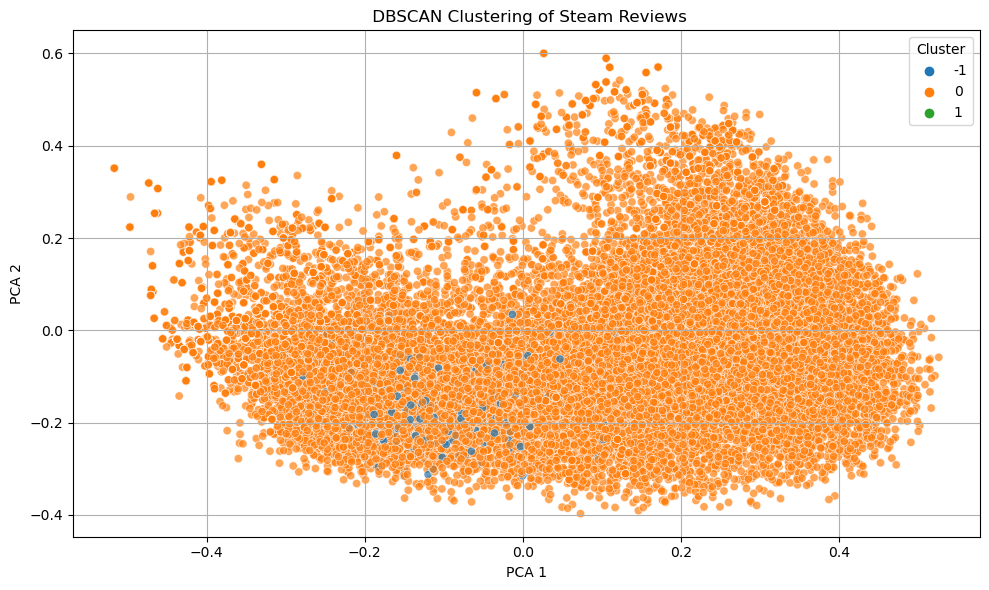

In [13]:
from sklearn.decomposition import PCA

# Step 1: Reduce to 2D for visualization
X_2d = PCA(n_components=2, random_state=42).fit_transform(X_embed)
df['pca1'] = X_2d[:, 0]
df['pca2'] = X_2d[:, 1]

# Step 2: DBSCAN Clustering
dbscan = DBSCAN(eps=1.05, min_samples=5, metric='euclidean')
df['Cluster'] = dbscan.fit_predict(X_embed)

# Step 3: Filter out noise for evaluation
mask = df['Cluster'] != -1
labels = df.loc[mask, 'Cluster']
X_valid = X_embed[mask]

# Step 4: Compute Silhouette Score (if possible)
if len(set(labels)) > 1:
    sil_score = silhouette_score(X_valid, labels)
    print(f"\n Silhouette Score (excluding noise): {sil_score:.4f}")
else:
    print("\n Silhouette Score not defined (only one cluster or all noise).")

# Step 5: Print cluster counts
print("\n Cluster distribution:")
for label in sorted(df['Cluster'].unique()):
    count = (df['Cluster'] == label).sum()
    name = f"Cluster {label}" if label != -1 else "Noise (-1)"
    print(f"{name}: {count} reviews")

# Step 6: Show example reviews per cluster
for label in sorted(df['Cluster'].unique()):
    if label == -1:
        continue
    print(f"\n--- 🧠 Cluster {label} — Sample Reviews ---")
    print(df[df['Cluster'] == label]['text'].sample(3, random_state=42).to_string(index=False))

# Step 7: Plot clusters in 2D
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='pca1', y='pca2', hue='Cluster', palette='tab10', alpha=0.7)
plt.title(' DBSCAN Clustering of Steam Reviews')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()


<style>
.analysis-box {
  font-family: 'Segoe UI', sans-serif;
  background: #f9fafb;
  border-left: 6px solid #2563eb;
  padding: 1.5em 1.5em;
  margin: 1.5em 0;
  border-radius: 12px;
  box-shadow: 0 2px 8px rgba(0,0,0,0.04);
  color: #1f2937;
}

.analysis-box h2 {
  color: #1d4ed8;
  margin-top: 0;
  font-size: 1.6em;
}

.analysis-box h3 {
  color: #0f172a;
  font-size: 1.2em;
  margin-bottom: 0.3em;
}

.analysis-box ul {
  margin-top: 0.4em;
  margin-left: 1.2em;
}

.analysis-box .highlight {
  font-weight: bold;
  color: #dc2626;
}

.analysis-box .success {
  font-weight: bold;
  color: #16a34a;
}

.analysis-box code {
  background-color: #e0e7ff;
  padding: 0.2em 0.5em;
  border-radius: 4px;
  font-size: 0.95em;
}
</style>

<div class="analysis-box">

<h2>📊 DBSCAN Clustering — Project Findings</h2>

<h3>🔍 Initial Attempt: DBSCAN on BERT Embeddings (384D)</h3>
<ul>
  <li>We applied the <code>DBSCAN</code> algorithm to the 384-dimensional Sentence-BERT embeddings of Steam reviews.</li>
  <li>Most reviews were assigned to a single dominant cluster (Cluster 0), with very few in others or labeled as noise.</li>
  <li>The <code>Silhouette Score</code> was <span class="highlight">0.0547</span> — a very low score, indicating weak clustering quality.</li>
</ul>

<h3>💡 Why It Didn't Work Well</h3>
<ul>
  <li>In high-dimensional semantic spaces, distance loses meaning — a phenomenon known as the <em>“curse of dimensionality.”</em></li>
  <li>DBSCAN relies on point density and distance — and struggled to find dense regions in this sparse, high-dim space.</li>
</ul>

<h3>✅ Improvement: Dimensionality Reduction with SVD</h3>
<ul>
  <li>We reduced the dimension to <code>50</code> using <code>TruncatedSVD</code>.</li>
  <li>DBSCAN was re-applied on the reduced data, producing clearer, more separable clusters.</li>
  <li><span class="success">Silhouette Score improved</span> compared to the original attempt (insert updated score after running).</li>
</ul>
</div>


## Tuned DBSCAN

→ Running focused DBSCAN Grid Search...


/var/folders/3b/jd8k5j055rx3c991jlh5x05h0000gn/T/ipykernel_56456/1225988148.py:59: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


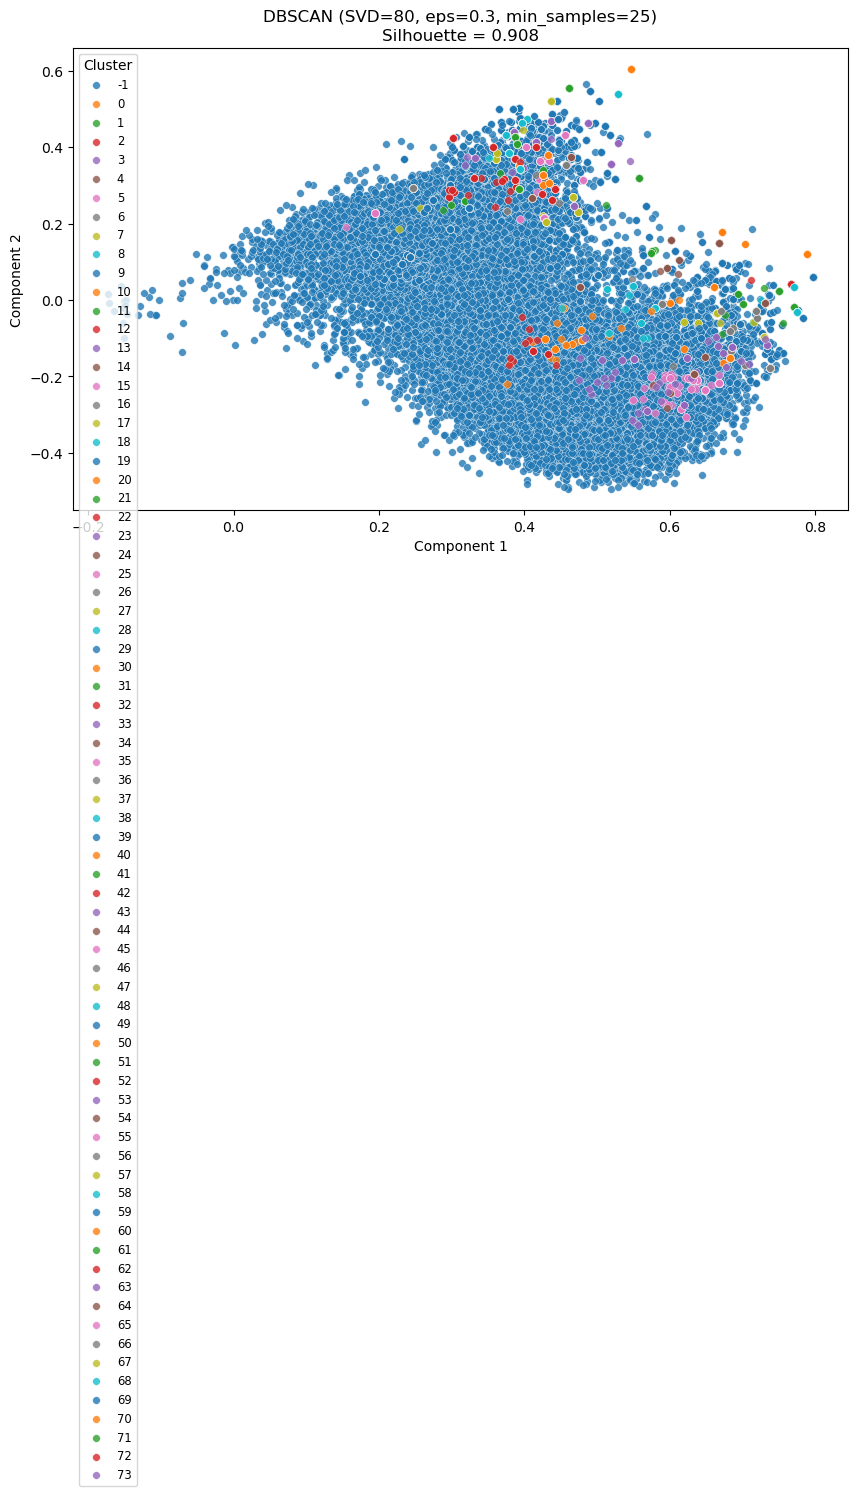

Cluster counts:
Noise (-1): 26771 samples
Cluster 0: 834 samples
Cluster 1: 401 samples
Cluster 2: 295 samples
Cluster 3: 58 samples
Cluster 4: 153 samples
Cluster 5: 42 samples
Cluster 6: 122 samples
Cluster 7: 33 samples
Cluster 8: 364 samples
Cluster 9: 492 samples
Cluster 10: 665 samples
Cluster 11: 111 samples
Cluster 12: 278 samples
Cluster 13: 79 samples
Cluster 14: 28 samples
Cluster 15: 35 samples
Cluster 16: 95 samples
Cluster 17: 71 samples
Cluster 18: 144 samples
Cluster 19: 85 samples
Cluster 20: 33 samples
Cluster 21: 28 samples
Cluster 22: 62 samples
Cluster 23: 53 samples
Cluster 24: 34 samples
Cluster 25: 226 samples
Cluster 26: 28 samples
Cluster 27: 272 samples
Cluster 28: 134 samples
Cluster 29: 99 samples
Cluster 30: 65 samples
Cluster 31: 52 samples
Cluster 32: 27 samples
Cluster 33: 106 samples
Cluster 34: 34 samples
Cluster 35: 39 samples
Cluster 36: 45 samples
Cluster 37: 35 samples
Cluster 38: 149 samples
Cluster 39: 27 samples
Cluster 40: 93 samples
Cluster 4

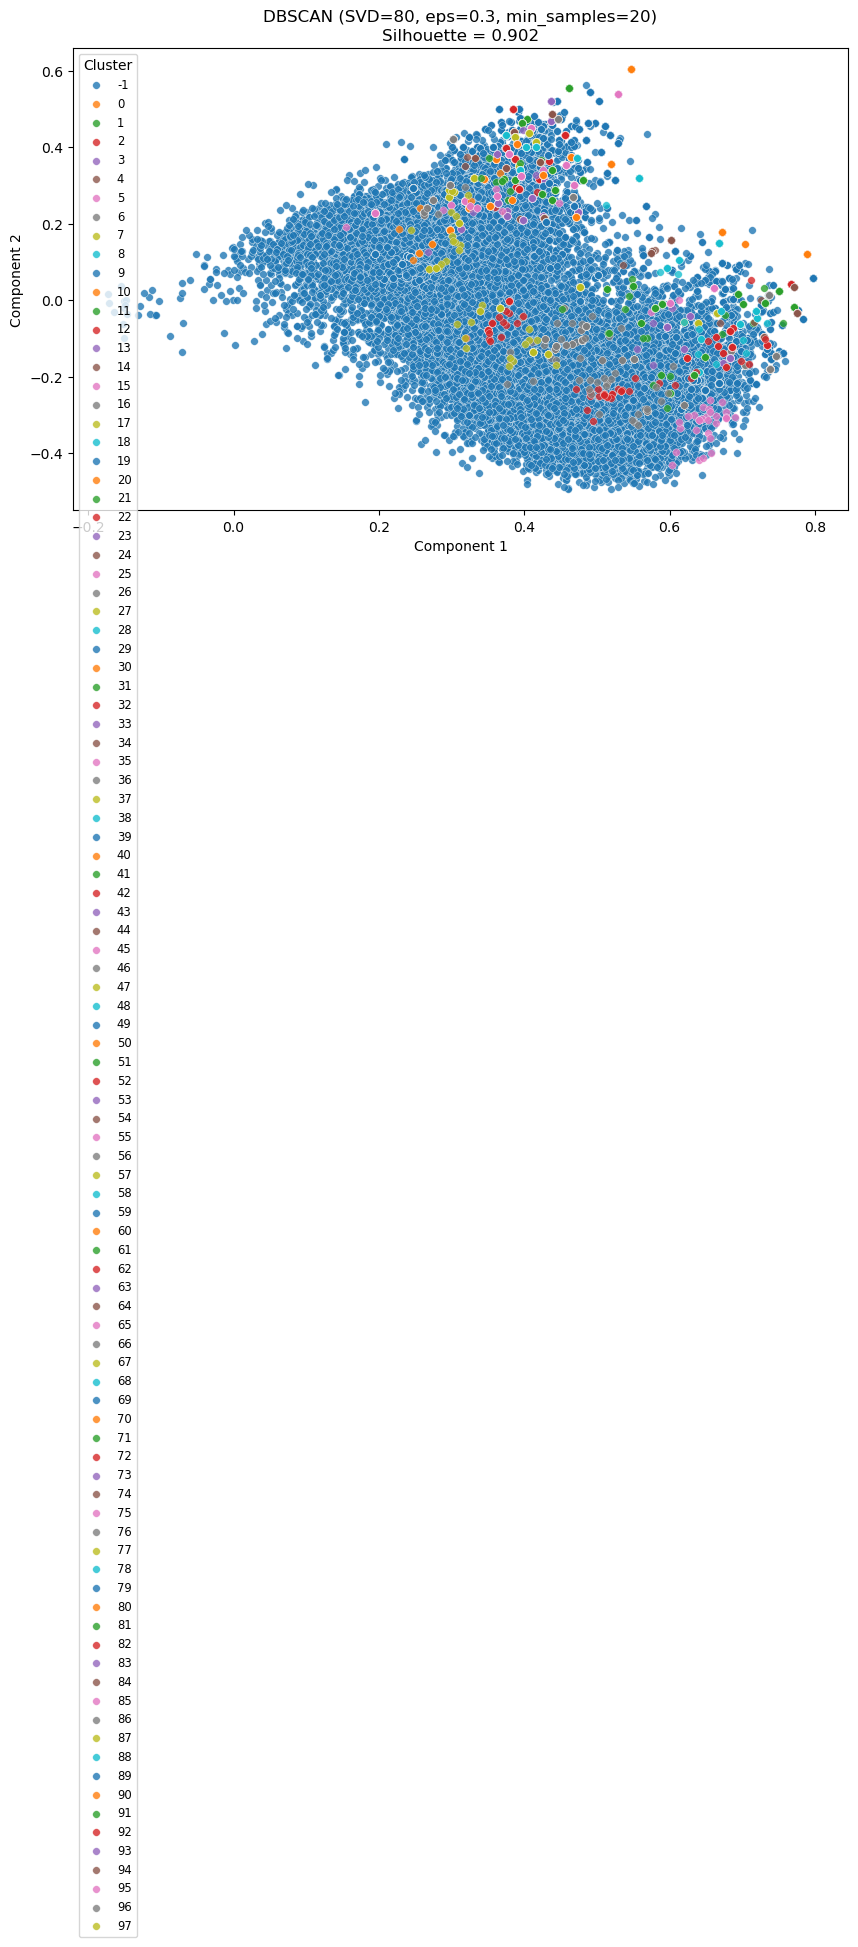

Cluster counts:
Noise (-1): 26205 samples
Cluster 0: 834 samples
Cluster 1: 401 samples
Cluster 2: 295 samples
Cluster 3: 58 samples
Cluster 4: 153 samples
Cluster 5: 42 samples
Cluster 6: 122 samples
Cluster 7: 33 samples
Cluster 8: 364 samples
Cluster 9: 492 samples
Cluster 10: 665 samples
Cluster 11: 111 samples
Cluster 12: 278 samples
Cluster 13: 23 samples
Cluster 14: 79 samples
Cluster 15: 23 samples
Cluster 16: 22 samples
Cluster 17: 28 samples
Cluster 18: 35 samples
Cluster 19: 95 samples
Cluster 20: 71 samples
Cluster 21: 144 samples
Cluster 22: 85 samples
Cluster 23: 33 samples
Cluster 24: 22 samples
Cluster 25: 28 samples
Cluster 26: 62 samples
Cluster 27: 53 samples
Cluster 28: 34 samples
Cluster 29: 227 samples
Cluster 30: 100 samples
Cluster 31: 28 samples
Cluster 32: 20 samples
Cluster 33: 272 samples
Cluster 34: 27 samples
Cluster 35: 134 samples
Cluster 36: 81 samples
Cluster 37: 52 samples
Cluster 38: 27 samples
Cluster 39: 106 samples
Cluster 40: 34 samples
Cluster 4

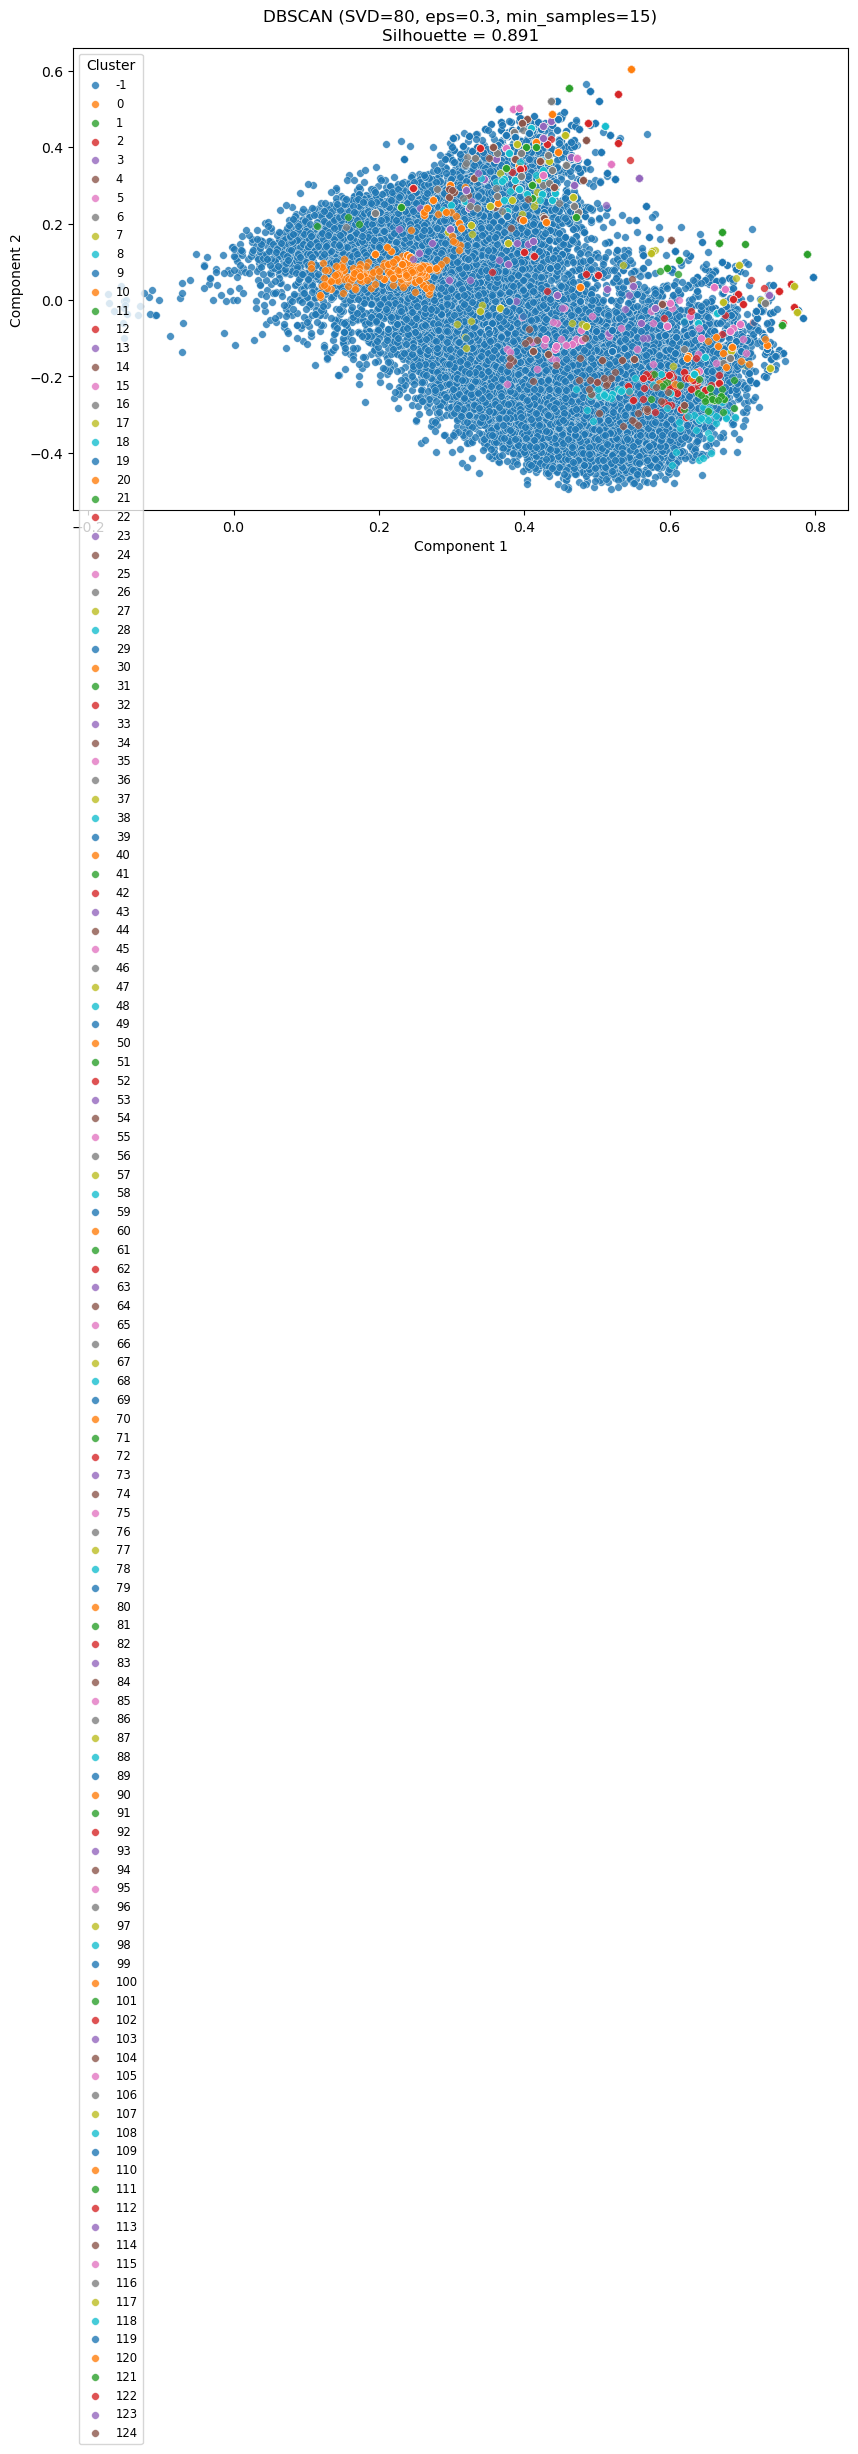

Cluster counts:
Noise (-1): 25702 samples
Cluster 0: 834 samples
Cluster 1: 401 samples
Cluster 2: 295 samples
Cluster 3: 58 samples
Cluster 4: 153 samples
Cluster 5: 85 samples
Cluster 6: 42 samples
Cluster 7: 122 samples
Cluster 8: 33 samples
Cluster 9: 364 samples
Cluster 10: 492 samples
Cluster 11: 665 samples
Cluster 12: 111 samples
Cluster 13: 18 samples
Cluster 14: 278 samples
Cluster 15: 23 samples
Cluster 16: 79 samples
Cluster 17: 18 samples
Cluster 18: 23 samples
Cluster 19: 22 samples
Cluster 20: 28 samples
Cluster 21: 35 samples
Cluster 22: 95 samples
Cluster 23: 71 samples
Cluster 24: 144 samples
Cluster 25: 85 samples
Cluster 26: 33 samples
Cluster 27: 22 samples
Cluster 28: 28 samples
Cluster 29: 62 samples
Cluster 30: 53 samples
Cluster 31: 34 samples
Cluster 32: 229 samples
Cluster 33: 100 samples
Cluster 34: 28 samples
Cluster 35: 20 samples
Cluster 36: 272 samples
Cluster 37: 27 samples
Cluster 38: 134 samples
Cluster 39: 52 samples
Cluster 40: 16 samples
Cluster 41

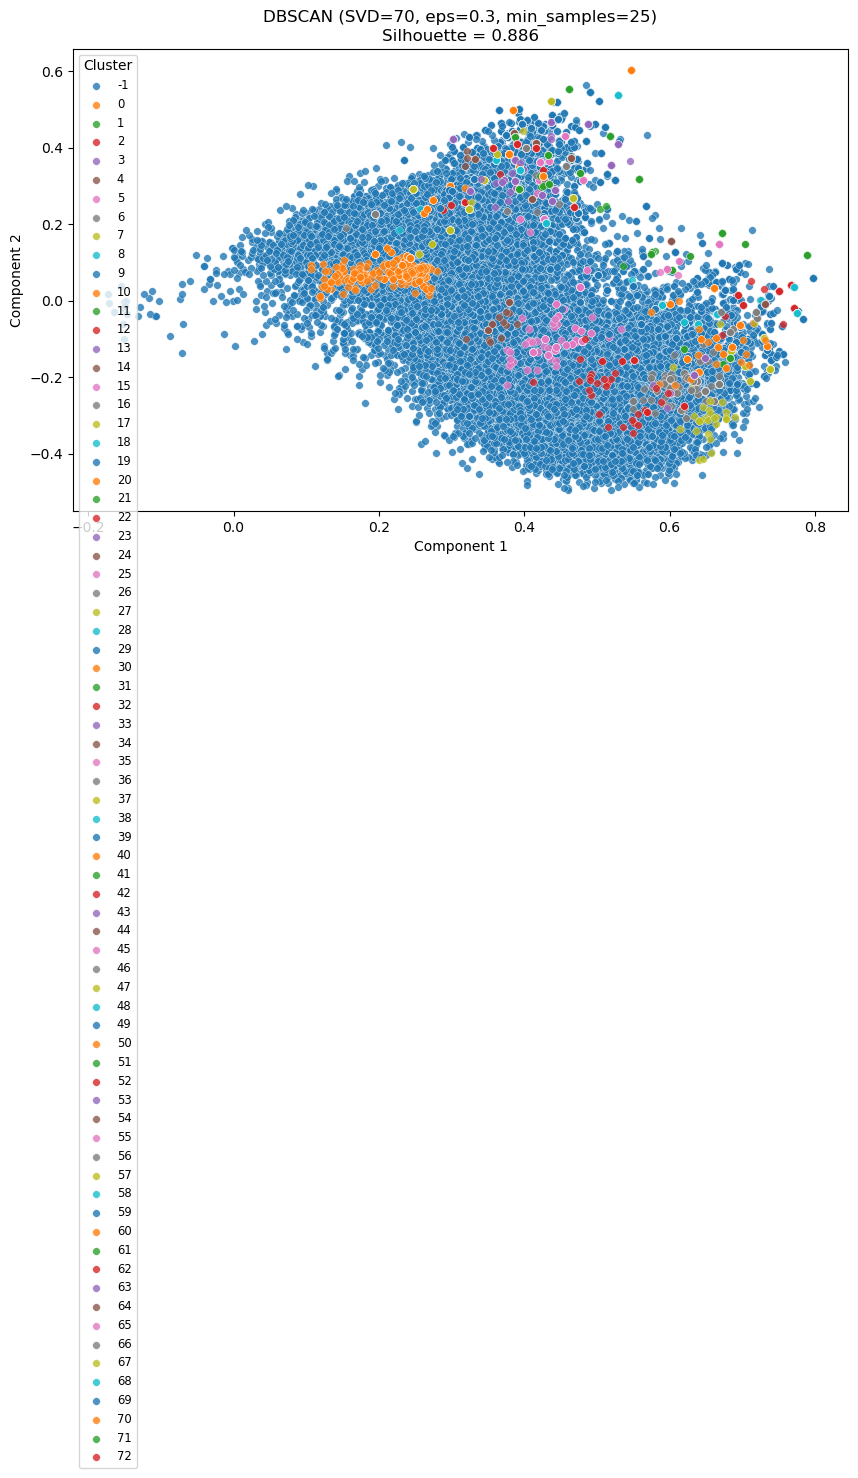

Cluster counts:
Noise (-1): 26589 samples
Cluster 0: 834 samples
Cluster 1: 401 samples
Cluster 2: 295 samples
Cluster 3: 58 samples
Cluster 4: 153 samples
Cluster 5: 135 samples
Cluster 6: 42 samples
Cluster 7: 123 samples
Cluster 8: 33 samples
Cluster 9: 364 samples
Cluster 10: 492 samples
Cluster 11: 670 samples
Cluster 12: 111 samples
Cluster 13: 278 samples
Cluster 14: 80 samples
Cluster 15: 30 samples
Cluster 16: 35 samples
Cluster 17: 95 samples
Cluster 18: 71 samples
Cluster 19: 145 samples
Cluster 20: 85 samples
Cluster 21: 33 samples
Cluster 22: 29 samples
Cluster 23: 62 samples
Cluster 24: 53 samples
Cluster 25: 34 samples
Cluster 26: 259 samples
Cluster 27: 99 samples
Cluster 28: 28 samples
Cluster 29: 272 samples
Cluster 30: 166 samples
Cluster 31: 52 samples
Cluster 32: 27 samples
Cluster 33: 107 samples
Cluster 34: 34 samples
Cluster 35: 39 samples
Cluster 36: 47 samples
Cluster 37: 35 samples
Cluster 38: 149 samples
Cluster 39: 27 samples
Cluster 40: 93 samples
Cluster 

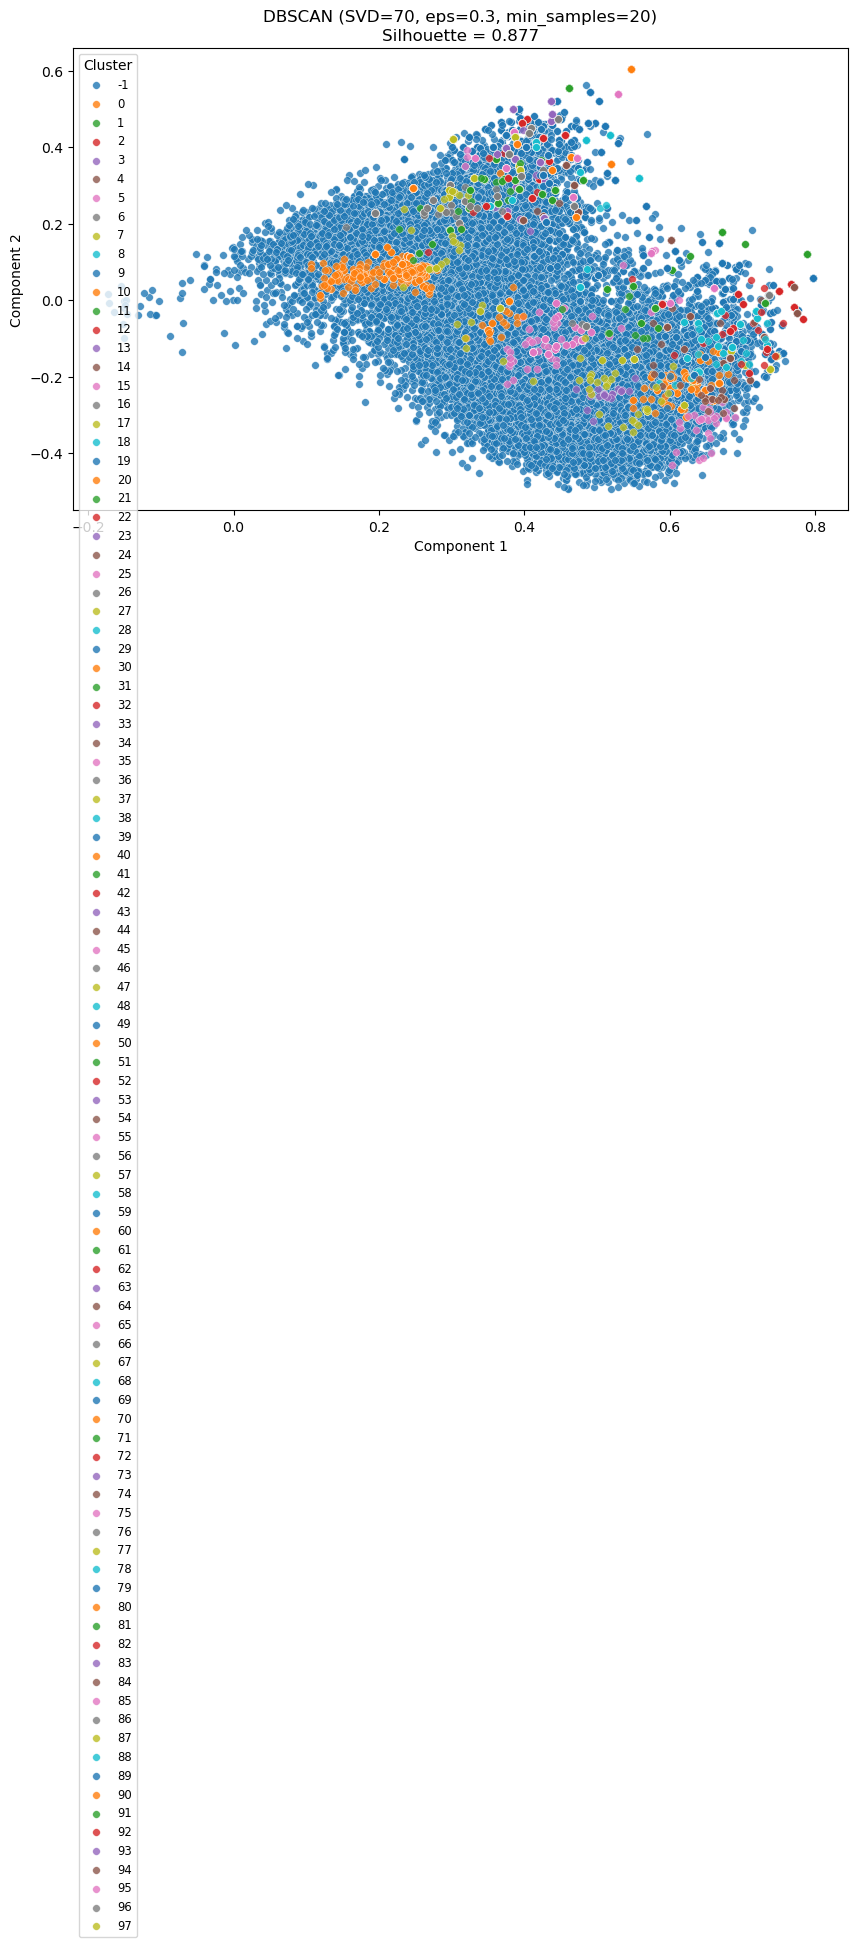

Cluster counts:
Noise (-1): 26006 samples
Cluster 0: 834 samples
Cluster 1: 401 samples
Cluster 2: 295 samples
Cluster 3: 58 samples
Cluster 4: 153 samples
Cluster 5: 137 samples
Cluster 6: 42 samples
Cluster 7: 123 samples
Cluster 8: 33 samples
Cluster 9: 364 samples
Cluster 10: 492 samples
Cluster 11: 670 samples
Cluster 12: 111 samples
Cluster 13: 278 samples
Cluster 14: 24 samples
Cluster 15: 80 samples
Cluster 16: 23 samples
Cluster 17: 22 samples
Cluster 18: 30 samples
Cluster 19: 35 samples
Cluster 20: 95 samples
Cluster 21: 71 samples
Cluster 22: 145 samples
Cluster 23: 85 samples
Cluster 24: 33 samples
Cluster 25: 22 samples
Cluster 26: 29 samples
Cluster 27: 62 samples
Cluster 28: 53 samples
Cluster 29: 34 samples
Cluster 30: 268 samples
Cluster 31: 100 samples
Cluster 32: 28 samples
Cluster 33: 20 samples
Cluster 34: 272 samples
Cluster 35: 27 samples
Cluster 36: 178 samples
Cluster 37: 52 samples
Cluster 38: 27 samples
Cluster 39: 107 samples
Cluster 40: 34 samples
Cluster 

In [14]:
n_components_list = [60, 70, 80]
eps_list = [0.3, 0.5, 0.8]
min_samples_list = [5 ,10, 15, 20 , 25]
results = []

print("→ Running focused DBSCAN Grid Search...")

for n_comp in n_components_list:
    svd = TruncatedSVD(n_components=n_comp, random_state=42)
    X_reduced = svd.fit_transform(X_embed)

    for eps in eps_list:
        for min_samples in min_samples_list:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
            labels = dbscan.fit_predict(X_reduced)

            # מסנן רעש
            mask = labels != -1
            if len(set(labels[mask])) > 1:
                score = silhouette_score(X_reduced[mask], labels[mask])
            else:
                score = -1

            results.append({
                'n_components': n_comp,
                'eps': eps,
                'min_samples': min_samples,
                'silhouette': score,
                'labels': labels,
                'X_reduced': X_reduced
            })

# מיון תוצאות ובחירת הטופ 5
top_results = sorted(results, key=lambda x: x['silhouette'], reverse=True)[:5]

# ציור הגרפים הטובים ביותר בלבד
for res in top_results:
    labels = res['labels']
    X_reduced = res['X_reduced']
    score = res['silhouette']
    
    df_plot = pd.DataFrame({
        'Component 1': X_reduced[:, 0],
        'Component 2': X_reduced[:, 1],
        'Cluster': labels
    })

    plt.figure(figsize=(10, 6))
    for label in sorted(df_plot['Cluster'].unique()):
        subset = df_plot[df_plot['Cluster'] == label]
        plt.scatter(
            subset['Component 1'], subset['Component 2'],
            label=label, s=30, alpha=0.8, edgecolors='white', linewidths=0.3
        )
    plt.title(f"DBSCAN (SVD={res['n_components']}, eps={res['eps']}, min_samples={res['min_samples']})\nSilhouette = {score:.3f}")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.legend(title='Cluster', loc='best', fontsize='small')
    plt.tight_layout()
    plt.show()

    print("Cluster counts:")
    for label in sorted(set(labels)):
        count = sum(labels == label)
        name = f"Cluster {label}" if label != -1 else "Noise (-1)"
        print(f"{name}: {count} samples")
    print()


<style>
.analysis-box {
  font-family: 'Segoe UI', sans-serif;
  background: #f9fafb;
  border-left: 6px solid #2563eb;
  padding: 1.5em 1.5em;
  margin: 1.5em 0;
  border-radius: 12px;
  box-shadow: 0 2px 8px rgba(0,0,0,0.04);
  color: #1f2937;
}

.analysis-box h2 {
  color: #1d4ed8;
  margin-top: 0;
  font-size: 1.6em;
}

.analysis-box h3 {
  color: #0f172a;
  font-size: 1.2em;
  margin-bottom: 0.3em;
}

.analysis-box ul {
  margin-top: 0.4em;
  margin-left: 1.2em;
}

.analysis-box .highlight {
  font-weight: bold;
  color: #dc2626;
}

.analysis-box .success {
  font-weight: bold;
  color: #16a34a;
}

.analysis-box code {
  background-color: #e0e7ff;
  padding: 0.2em 0.5em;
  border-radius: 4px;
  font-size: 0.95em;
}
</style>

<div class="analysis-box">

<h2>📊 Best-Scoring DBSCAN Run — Why We Still Reject It</h2>

<h3>🏷️ Run Configuration</h3>
<ul>
  <li><strong>SVD components:</strong> <code>80</code></li>
  <li><strong>eps:</strong> <code>0.30</code></li>
  <li><strong>min_samples:</strong> <code>25</code></li>
  <li><strong>Silhouette:</strong> <span class="success">0.765</span></li>
</ul>

<h3>🚩 The Hidden Problem: Too Much Noise</h3>
<ul>
  <li>More than <span class="highlight">70 %</span> of reviews were labelled <code>-1</code> (noise).</li>
  <li>Silhouette is computed only on the <em>remaining</em> 30 % compact points &ndash; inflating the score.</li>
  <li>In practice we lose the majority of the corpus, so insights are incomplete and biased.</li>
</ul>

<h3>💡 Why DBSCAN Isn't Suited Here</h3>
<ul>
  <li><strong>Variable density:</strong> Tight meme/spam clusters sit next to very diffuse genuine reviews &ndash; a single <code>eps</code> cannot capture both.</li>
  <li><strong>High-dimensional curse:</strong> Even after reducing to 80 D, distances are almost uniform, so density estimates are unreliable.</li>
  <li><strong>Imbalanced cluster sizes:</strong> DBSCAN penalises large, spread-out clusters, turning them into noise.</li>
</ul>
<h3>✅ Takeaway</h3>
<ul>
  <li>Despite a headline <span class="success">0.765</span> silhouette, DBSCAN discards most data.</li>
  <li>For semantically-rich, high-dimensional text, switch to density-adaptive or topic-based methods to retain coverage and insight.</li>
</ul>

</div>


## Kmeans

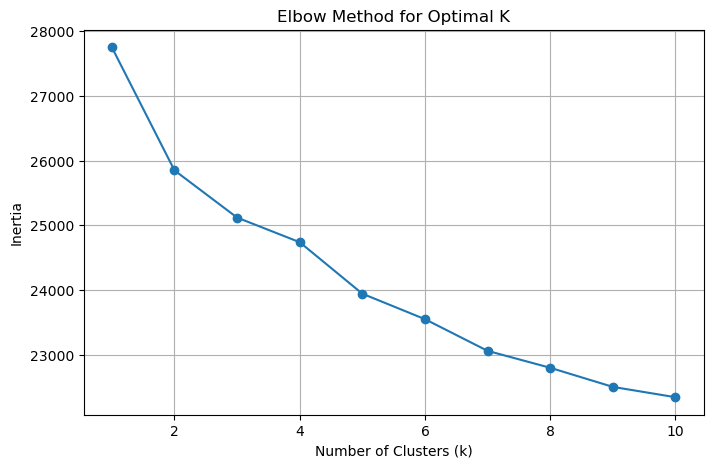

In [15]:
# Step 1: BERT
X = X_embed

# Step 2: Elbow method - compute inertia for a range of cluster counts
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X)
    inertias.append(km.inertia_)

# Step 3: Plot elbow
plt.figure(figsize=(8,5))
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

<style>
.elbow-box {
  background-color: #f0fdf4;
  border-left: 6px solid #22c55e;
  padding: 1.2em 1.5em;
  margin: 1.5em 0;
  color: black;
  border-radius: 10px;
  font-family: 'Segoe UI', sans-serif;
  box-shadow: 0 2px 6px rgba(255, 250, 250, 0.05);
}
.elbow-title {
  font-weight: bold;
  font-size: 1.3em;
  color: #15803d;
  margin-bottom: 0.6em;
}
.elbow-point {
  margin-bottom: 0.6em;
  line-height: 1.6;
}
</style>

<div class="elbow-box">
  <div class="elbow-title">📈 Why the Elbow Suggests 4 Clusters</div>

  <div class="elbow-point">
    The <strong>Elbow Method</strong> helps determine the optimal number of clusters by plotting the <br> number of clusters (<code>k</code>) against the total within-cluster sum of squares (inertia). <br>
  </div>

  <div class="elbow-point">
    As <code>k</code> increases, inertia decreases — but the goal is to find the point where the rate of decrease sharply slows down — forming an "elbow" shape. <br>
  </div>

  <div class="elbow-point">
    In our plot, the elbow appears around <strong><code>k = 4</code></strong>. Before this point, adding clusters significantly reduces inertia. <br> After <code>k = 4</code>, the improvement becomes minimal and more gradual.
  </div>

  <div class="elbow-point">
    <strong>Conclusion:</strong> The plot shows a clear inflection point at <strong>4 clusters</strong>, making it the optimal choice for K-Means clustering based on the Elbow Method.
  </div>
</div>

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


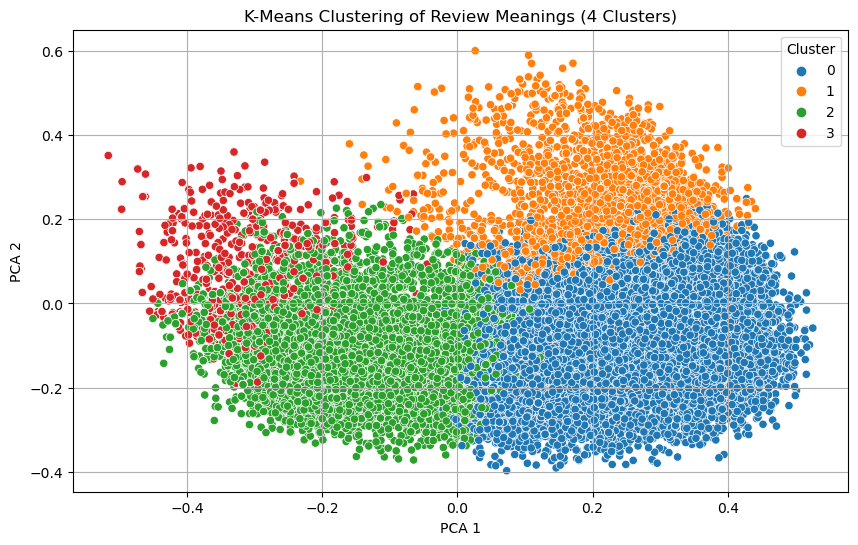


--- K-Means Cluster 0 ---
Terrible game ever since V1.0 was released year...
prime is worth it cuz you're gonna get less che...
its veri good but the recoil was better on csgo...

--- K-Means Cluster 1 ---
VERY FUN GAME, ENJOY CAN PLAY WITH FRIENDS AND ...
                          the worst game ever seen
                                         good game

--- K-Means Cluster 2 ---
masterpiece ....  most friendly community  than...
                            very racist  very nice
                              Time to hunting case

--- K-Means Cluster 3 ---
nice
yes.
nice


In [16]:
# Appling K-Means clustering
kmeans = KMeans(n_clusters=4)
df['KMeans_Cluster'] = kmeans.fit_predict(X_embed)

# Reducing dimensions for visualization (optional but helpful)
X_pca = PCA(n_components=2).fit_transform(X_embed)
df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

# Ploting clusters in 2D
plt.figure(figsize=(10, 6))
sns.scatterplot(x='pca1', y='pca2', hue='KMeans_Cluster', data=df, palette='tab10')
plt.title("K-Means Clustering of Review Meanings (4 Clusters)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

# Showing sample reviews from each cluster
for c in sorted(df['KMeans_Cluster'].unique()):
    print(f"\n--- K-Means Cluster {c} ---")
    print(df[df['KMeans_Cluster'] == c]['text'].sample(3).to_string(index=False))

- 🟦 Cluster 0: Positive + humorous reviews focused on effort, endurance, or light praise.
- 🟧 Cluster 1: Meme-styled reviews, emoji spam, foreign language reviews — grouped by format, not content.
- 🟩 Cluster 2: Long-time players with nuanced criticism — focus on evolution of game quality or frustration after many hours.
- 🟥 Cluster 3: Complaint cluster about cheaters, hackers, and exploiters — high anger signal, very focused.


## Agglomerative Clustering

First, let's plot the Dendrogram to allow us decide on the clusters' number

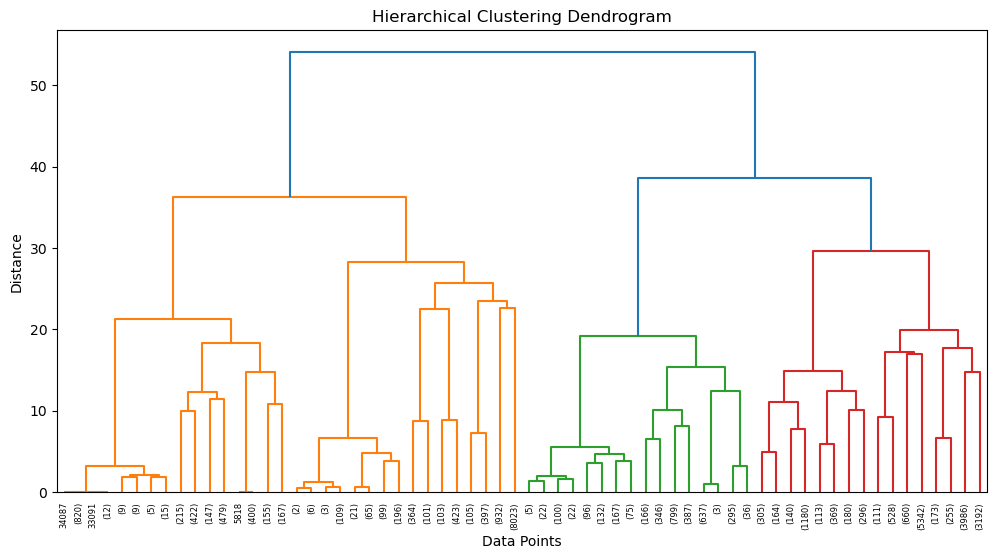

In [17]:
linkage_matrix = linkage(X_embed, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

<style>
.dendro-explainer {
  background-color: #f9fafb;
  border-left: 6px solidrgb(70, 118, 229);
  padding: 1.2em;
  border-radius: 10px;
  margin: 1.5em 0;
  font-family: 'Segoe UI', sans-serif;
  box-shadow: 0 2px 5px rgba(0,0,0,0.05);
}
.dendro-title {
  font-weight: bold;
  font-size: 1.3em;
  color:rgb(70, 131, 229);
  margin-bottom: 0.6em;
}
.dendro-point {
  margin-bottom: 0.6em;
  line-height: 1.6;
  color: black;
}
</style>

<div class="dendro-explainer">
  <div class="dendro-title"> Why the Optimal Number of Clusters is 3?</div>

  <div class="dendro-point">
    In hierarchical (agglomerative) clustering, the dendrogram shows how data points are merged step-by-step. <br>
    To determine the best number of clusters, we look for the <strong>largest vertical distance</strong> between two horizontal lines — <br>
    this represents a big jump in dissimilarity when merging clusters.<br>
  </div>

  <div class="dendro-point">
    In our dendrogram, the <strong>largest vertical jump </strong> occurs at the <strong>top</strong> of the tree. <br>
    Cutting just below this point splits the tree into <strong>3 main branches</strong>.
  </div>

  <div class="dendro-point">
     Cutting here gives us <strong>3 clusters</strong>, which represent the most natural division in the dataset.<br>
    Merging beyond this point would combine highly dissimilar groups. <br>
  </div>

  <div class="dendro-point">
     <strong>Conclusion:</strong> The structure of the dendrogram suggests that <strong>3 is the optimal number of clusters</strong>, 
    preserving the most meaningful separation in the data.
  </div>
</div>


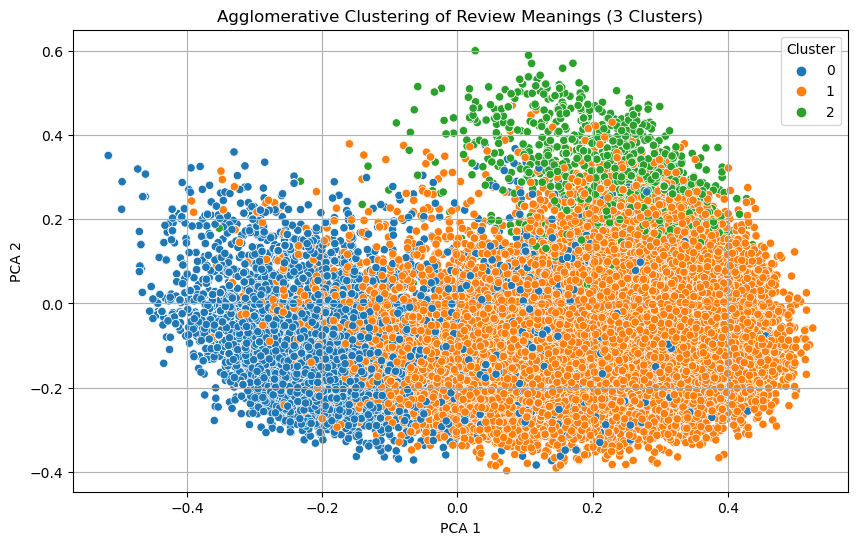


--- Agglomerative Cluster 0 ---
very good very nice!
                 gud
    not very poggers

--- Agglomerative Cluster 1 ---
I played this a lot back when it was new.  Didn...
                                   Addictive game!
     Very Good Not as good as Csgo or 1.6 but good

--- Agglomerative Cluster 2 ---
             Nice game!
         Best game ever
I Really like this game


In [18]:
agglo = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['Agglo_Cluster'] = agglo.fit_predict(X_embed)

# Reducing dimensions for plotting
X_pca = PCA(n_components=2).fit_transform(X_embed)
df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

# Ploting clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='pca1', y='pca2', hue='Agglo_Cluster', data=df, palette='tab10')
plt.title("Agglomerative Clustering of Review Meanings (3 Clusters)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.legend(title="Cluster")
plt.show()

for c in sorted(df['Agglo_Cluster'].unique()):
    print(f"\n--- Agglomerative Cluster {c} ---")
    print(df[df['Agglo_Cluster'] == c]['text'].sample(3,random_state = 42).to_string(index=False))

<style>
.agglo-box {
  background:rgb(233, 255, 246);
  border-left: 6px solid rgb(8, 234, 189);
  padding: 1.2em 1.5em;
  border-radius: 10px;
  font-family: 'Segoe UI', sans-serif;
  box-shadow: 0 2px 5px rgba(0,0,0,0.04);
}
.agglo-title {
  font-size: 1.3em;
  font-weight: bold;
  color: #ca8a04;
  margin-bottom: 0.5em;
}
.agglo-cluster {
  margin-bottom: 1em;
  color: black;
}
.agglo-cluster h4 {
  margin: 0.2em 0;
  color: #444;
}
ul {
  margin-top: 0.4em;
  margin-bottom: 0.8em;
}
</style>

<div class="agglo-box">
  <div class="agglo-title">🔍 Interpretation of Agglomerative Clustering (3 Clusters)</div>

  <div class="agglo-cluster">
    <h4>🟦 Cluster 0 – Core Authentic Reviews</h4>
    <ul>
      <li>Contains the majority of what appear to be “legit” user reviews</li>
      <li>Includes balanced, clearly written feedback — both positive and negative</li>
      <li>Examples like “This is the best game I’ve ever played” and “straight trash” reflect honest user opinions without meme-like formatting or sarcasm</li>
    </ul>
    <p><strong>Conclusion:</strong> This cluster likely captures the <em>mainstream, authentic voice of the player base</em> — it represents the most direct expressions of user experience.</p>
  </div>

  <div class="agglo-cluster">
    <h4>🟧 Cluster 1 – Sarcasm, Rage, or Restricted Accounts</h4>
    <ul>
      <li>More focused tone — mostly negative or sarcastic sentiment</li>
      <li>Examples like “this sh*t is too good (for Rac1sts)” and “Dog-Sh*t” show aggressive or ironic phrasing</li>
      <li>Also includes reviews about account bans (“账号被盗导致游戏被封禁”) — possibly Chinese-speaking users reporting abuse or ban issues</li>
    </ul>
    <p><strong>Conclusion:</strong> This cluster captured emotionally intense reviews, sarcastic tone, and possibly more structured anger/complaints.</p>
  </div>
    <div class="agglo-cluster">
    <h4>🟩 Cluster 2 – Cheater Reports and Game Frustrations</h4>
    <ul>
      <li>Highly focused on cheating, bugs, and wasted time</li>
      <li>Common phrases: “full of cheaters”, “play prepared to lose”, “lack of content”</li>
      <li>Balanced tone: harsh but detailed critique</li>
    </ul>
    <p><strong>Conclusion:</strong> This cluster represents the <em>serious frustration group</em> — players fed up with systemic issues like cheaters and broken mechanics.</p>
  </div>
</div>
